In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics import silhouette_score
import matplotlib.colors as mcolors

In [3]:
df = pd.read_csv('official_finaldataset.csv')


# K-MEANS

Dopo aver selezionato delle features, ho applicato la tecnica di normalizzazione Min-Max che trasforma i valori di ogni feature in un intervallo specificato, solitamente tra 0 e 1. 

In [4]:
features = [
   "GameWeight",           # Complessità
    "PlaytimeComAvg",       # Durata
    "MinPlayers",
    #"MaxPlayers",           # Esperienza
    "log_NumUserRatings",
    #"ComAgeRec",
   #"InterestScore",
   #"log_NumWeightVotes",
   #"NumAlternates_log",
   # "NumExpansions_log",
   # "NumImplementations_log"
]

X = df[features] 

# scaler = StandardScaler() # z-score per le prove
scaler = MinMaxScaler()

# Applica lo scaling
X_scaled = scaler.fit_transform(X)

# Se vuoi trasformarlo ancora in DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=features)

## SSE - Elbow Method & Silhouette Score

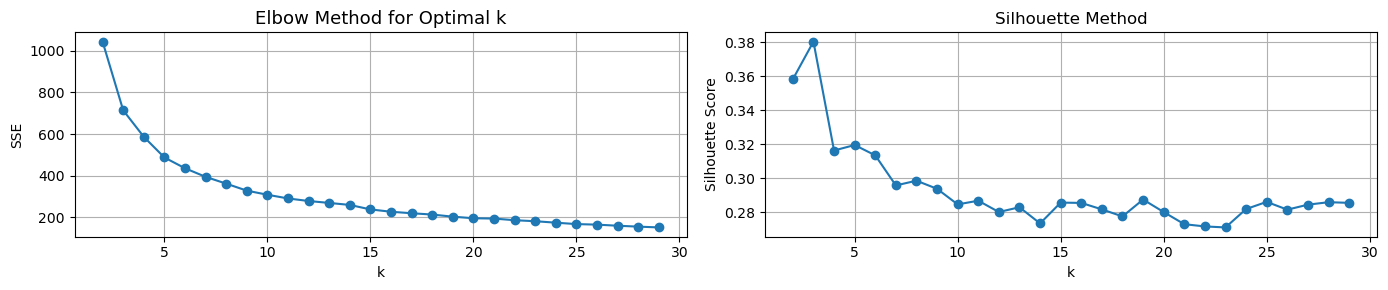

In [5]:
# Lista per raccogliere i valori di SSE e silhouette score
inertia = []
silhouette_scores = []
K = range(2, 30)

# Crea i subplots (1 riga, 2 colonne)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3))

# Grafico 1: Elbow Method (SSE)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

ax1.plot(K, inertia, marker='o')
ax1.set_xlabel('k')
ax1.set_ylabel('SSE')
ax1.set_title('Elbow Method for Optimal k', size=13)
ax1.grid(True)  # Aggiungi la griglia al primo grafico

# Grafico 2: Silhouette Score
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

ax2.plot(K, silhouette_scores, marker='o')
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Method")
ax2.grid(True)  # Aggiungi la griglia al secondo grafico

# Aggiungi un layout migliore per evitare sovrapposizioni
plt.tight_layout()

# Mostra il grafico
plt.show()


In [6]:
print("Inertia values for different k:")
for k, inert in zip(K, inertia):
    print(f"k={k}, SSE={inert}")

Inertia values for different k:
k=2, SSE=1043.3905097156774
k=3, SSE=713.9874664682721
k=4, SSE=586.8253219698643
k=5, SSE=487.76295678113536
k=6, SSE=436.09998528491303
k=7, SSE=394.9057951751348
k=8, SSE=362.2730510499326
k=9, SSE=328.67143716110894
k=10, SSE=309.0503397285371
k=11, SSE=291.23488776541205
k=12, SSE=278.9874721410946
k=13, SSE=269.763810679394
k=14, SSE=260.1642512274952
k=15, SSE=238.68386572465403
k=16, SSE=227.46902356586276
k=17, SSE=220.3133875131826
k=18, SSE=214.01414729098843
k=19, SSE=203.8586673085004
k=20, SSE=196.31095255641034
k=21, SSE=194.78165885308044
k=22, SSE=186.87939098588373
k=23, SSE=182.08117477239597
k=24, SSE=175.03248813639271
k=25, SSE=168.2752600627398
k=26, SSE=165.72512544992816
k=27, SSE=160.3869408552326
k=28, SSE=156.11640587896915
k=29, SSE=152.26554941479154


In [7]:
print("Silhouette scores for different k:")
for k, score in zip(K, silhouette_scores):
    print(f"k={k}, Silhouette Score={score}")

Silhouette scores for different k:
k=2, Silhouette Score=0.3582879206500835
k=3, Silhouette Score=0.3804554310346738
k=4, Silhouette Score=0.3163473851326338
k=5, Silhouette Score=0.3195707326204859
k=6, Silhouette Score=0.3135030108966656
k=7, Silhouette Score=0.2957865136275874
k=8, Silhouette Score=0.2985640773895458
k=9, Silhouette Score=0.29379841818578595
k=10, Silhouette Score=0.28460908942658597
k=11, Silhouette Score=0.2867924726372339
k=12, Silhouette Score=0.2801220609949426
k=13, Silhouette Score=0.2829380847977839
k=14, Silhouette Score=0.2733991342813632
k=15, Silhouette Score=0.28567084190808245
k=16, Silhouette Score=0.28548665696412967
k=17, Silhouette Score=0.28167555170620456
k=18, Silhouette Score=0.2775285443155098
k=19, Silhouette Score=0.28747427987053714
k=20, Silhouette Score=0.28010396850478686
k=21, Silhouette Score=0.2729527884269375
k=22, Silhouette Score=0.27163851615476386
k=23, Silhouette Score=0.27104879131016696
k=24, Silhouette Score=0.281878732727237

Di default, KMeans calcola internamente la distanza tra i punti e i centri dei cluster usando la distanza euclidea

In [8]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

#num_cols = df.select_dtypes(include=["number"]).columns
df.groupby("cluster")[features].mean()



,GameWeight,PlaytimeComAvg,MinPlayers,log_NumUserRatings
cluster,,,,
0,2.698350,83.817423,1.843750,7.835043
1,1.232203,30.556340,2.151026,4.317041
2,2.182504,65.498866,1.964853,4.398000
3,1.590746,36.628264,2.104199,6.513567
4,3.301958,210.224373,1.835290,4.767793


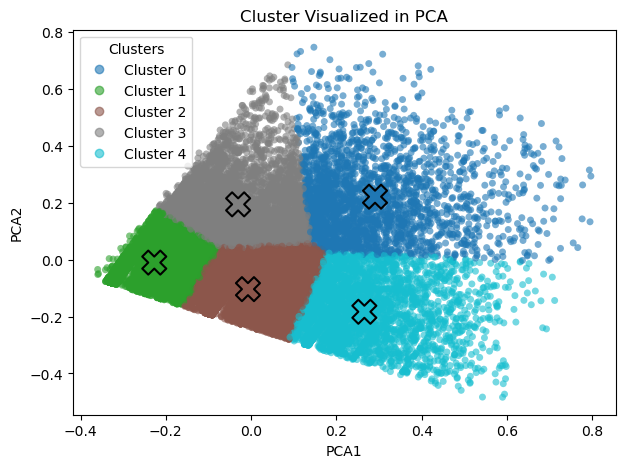

In [9]:
# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

df["PCA1"] = pca_result[:, 0]
df["PCA2"] = pca_result[:, 1]

# Compute centroids in PCA space
centroids = df.groupby("cluster")[["PCA1", "PCA2"]].mean()

plt.figure(figsize=(7, 5))

# Crea una lista di colori associati ai cluster, ordinata per cluster
cmap = plt.get_cmap("tab10")
unique_clusters = sorted(df["cluster"].unique())  # Ordina i cluster

# Scatter plot dei punti dei cluster
scatter = plt.scatter(
    df["PCA1"], df["PCA2"],
    c=df["cluster"],
    cmap=cmap,
    alpha=0.6,
    s=25,
    edgecolor="none"
)

# Plot dei centroidi
plt.scatter(
    centroids["PCA1"], centroids["PCA2"],
    c=centroids.index,
    cmap=cmap,
    s=300,
    marker="X",
    edgecolor="black",
    linewidth=1.5,
    label="Centroids"
)

# Aggiungi la legenda
handles, labels = scatter.legend_elements()
plt.legend(handles=handles, labels=[f"Cluster {i}" for i in unique_clusters], title="Clusters")

# Etichette e titolo
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("Cluster Visualized in PCA")

plt.show()


In [10]:
# Varianza spiegata da ogni componente
explained_variance = pca.explained_variance_ratio_

# Stampa delle prime due componenti
print("Explained variance ratio:")
print(f"PC1: {explained_variance[0]*100:.2f}%")
print(f"PC2: {explained_variance[1]*100:.2f}%")
print(f"PC1 + PC2: {(explained_variance[0] + explained_variance[1])*100:.2f}%")

Explained variance ratio:
PC1: 54.56%
PC2: 37.75%
PC1 + PC2: 92.31%


In [11]:
from collections import Counter

# Conta quanti punti in ogni cluster
cluster_counts = Counter(kmeans.labels_)
total_points = len(kmeans.labels_)

# Calcola le percentuali
for cluster, count in sorted(cluster_counts.items()):
    percentage = (count / total_points) * 100
    print(f"Cluster {cluster}: {count} punti ({percentage:.2f}%)")

# Oppure più semplicemente
print(f"Max %: {max(cluster_counts.values()) / total_points * 100:.2f}")
print(f"Min %: {min(cluster_counts.values()) / total_points * 100:.2f}")

Cluster 0: 2336 punti (10.86%)
Cluster 1: 5946 punti (27.64%)
Cluster 2: 6174 punti (28.70%)
Cluster 3: 3906 punti (18.16%)
Cluster 4: 3151 punti (14.65%)
Max %: 28.70
Min %: 10.86


In [12]:
# differenze tra cluster
cluster_means = df.groupby("cluster")[features].mean()

# ordina le variabili per varianza tra i cluster
diff = cluster_means.var().sort_values(ascending=False)
print(diff)


PlaytimeComAvg        5341.544485
log_NumUserRatings       2.401925
GameWeight               0.692696
MinPlayers               0.021102
dtype: float64


Interpretazione => PlaytimeComAvg (5375) — la variabile che separa di più i cluster  
La varianza tra i cluster è enorme = significa che la durata media di gioco è la dimensione che più distingue i gruppi.

<Figure size 1200x600 with 0 Axes>

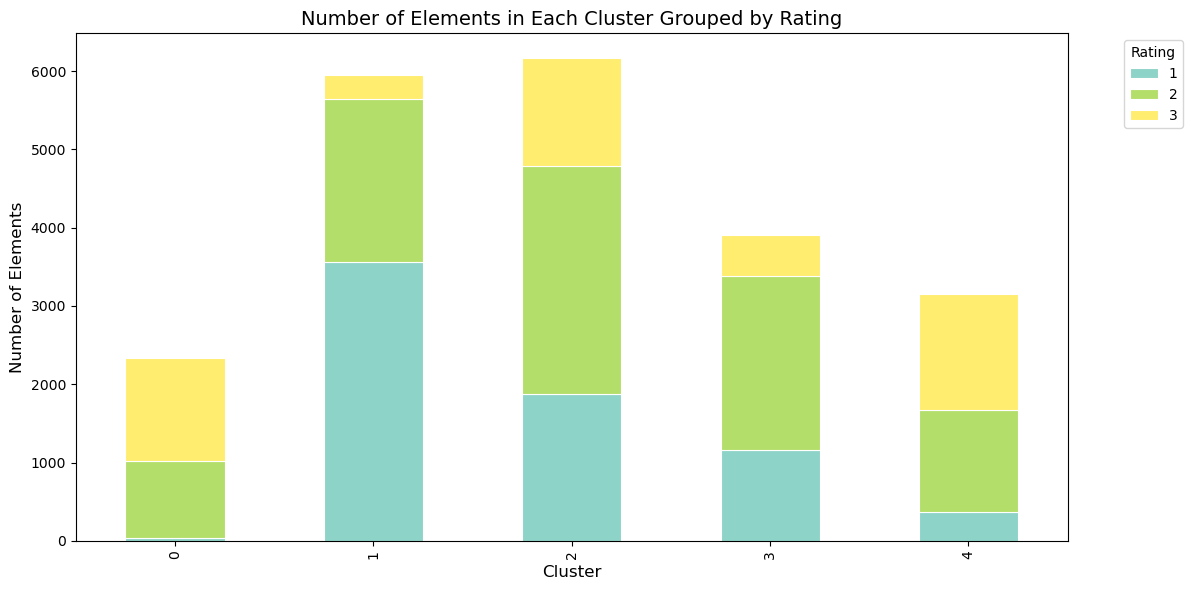

In [13]:
# Count how many items of each discrete rating fall into each cluster
rating_dist = pd.crosstab(df["cluster"], df["Rating"])

plt.figure(figsize=(12, 6))

rating_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    colormap="Set3",
    edgecolor="white",     # outline each segment
    linewidth=0.8
) # colorful palette similar to your example


plt.title("Number of Elements in Each Cluster Grouped by Rating", fontsize=14)
plt.xlabel("Cluster", fontsize=12)
plt.ylabel("Number of Elements", fontsize=12)
plt.legend(title="Rating", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


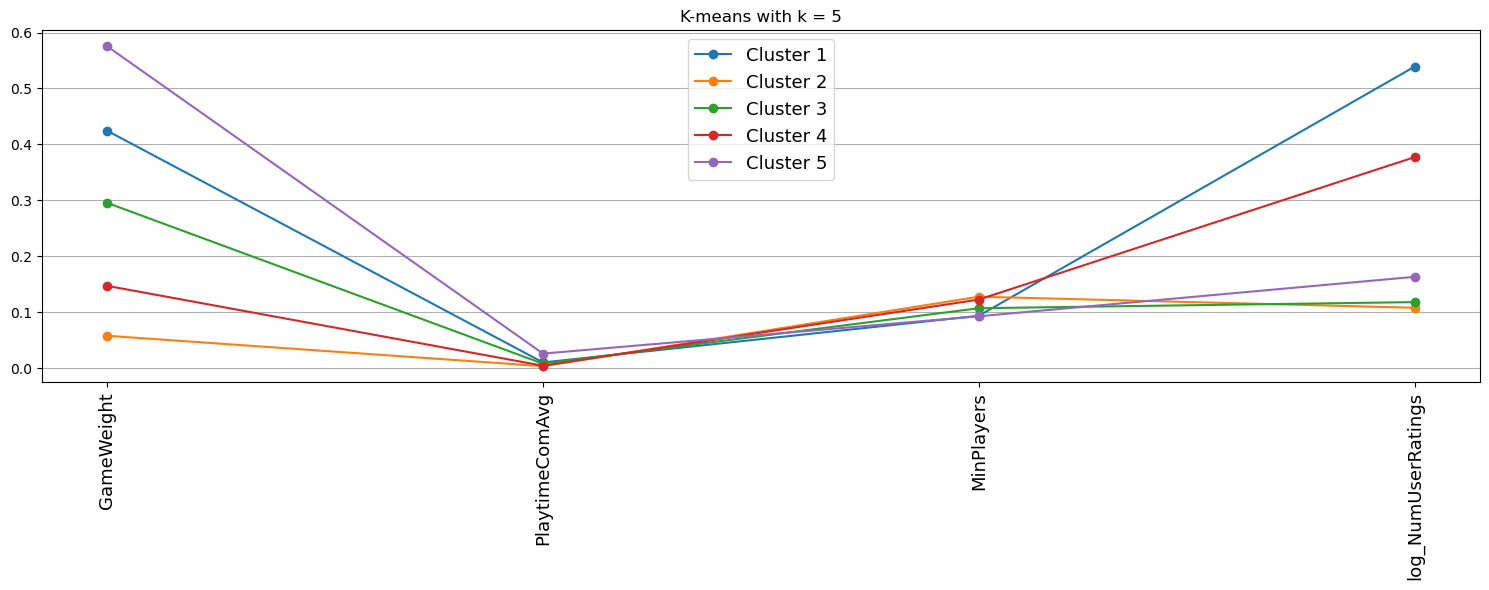

In [14]:
def cluster_distances_plot(data, kmeans, title, column_names=None, selected_features=None):
    """
    Traccia i centroidi dei cluster usando solo le feature selezionate.
    
    Parameters:
    - data: Dati su cui è stato eseguito il clustering
    - kmeans: Il modello di clustering KMeans
    - title: Titolo del grafico
    - column_names: Nomi delle colonne se sono disponibili
    - selected_features: Lista delle feature da visualizzare (opzionale)
    """
    clust_name = [str(i) for i in range(1, kmeans.n_clusters + 1)]
    centers = kmeans.cluster_centers_

    # Se column_names non è passato, usa i nomi di colonna di `data` (assumendo che data sia un DataFrame pandas)
    if column_names is not None:
        data = pd.DataFrame(data, columns=column_names)
    else:
        # Se `data` è un numpy.ndarray e non un DataFrame, dovresti passare manualmente i nomi delle colonne
        data = pd.DataFrame(data, columns=[f'Feature {i}' for i in range(data.shape[1])])

    # Se sono specificate delle feature selezionate, usale
    if selected_features:
        data = data[selected_features]
    
    # Aggiungi le etichette del cluster come colonna
    data = data.assign(kmeans_labels=kmeans.labels_)

    cluster_sizes = data['kmeans_labels'].value_counts()

    # Aumenta la larghezza per gestire le etichette lunghe
    plt.figure(figsize=(15, 6))  # Aumenta la larghezza per visualizzare meglio le etichette

    for i in range(len(centers)):
        plt.plot(centers[i], marker='o', label='Cluster ' + clust_name[i])

    # Usa i nomi delle colonne originali (escludendo kmeans_labels)
    plt.xticks(range(len(data.columns) - 1), data.columns[:-1], fontsize=13)  # Escludi 'kmeans_labels' dal grafico
    plt.legend(fontsize=13, loc='best')
    plt.title(title)
    plt.grid(axis='y')

    # Ruota le etichette di 90 gradi per una migliore leggibilità
    plt.xticks(rotation=90)
    plt.tight_layout()  # Per evitare sovrapposizioni
    plt.show()

# Esegui la funzione con il tuo clustering KMeans
features = [
    "GameWeight",           # Complessità
    "PlaytimeComAvg",       # Durata
    "MinPlayers",           # Esperienza
    "log_NumUserRatings",   # Popolarità (solo 1!)
]
  
# Sostituisci con le tue feature desiderate
cluster_distances_plot(data=X_scaled, kmeans=kmeans, title="K-means with k = 5", column_names=df.columns, selected_features=features)
